<a href="https://colab.research.google.com/github/GabsPassos/hospital_supply_chain/blob/main/hospital_supply_chain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto: Auditoria e Análise de Supply Chain Hospitalar
Este notebook apresenta o saneamento, tratamento e análise exploratória de dados macrofinanceiros de uma instituição de saúde. O objetivo é corrigir inconsistências de registros e extrair insights sobre os fluxos de despesas.


In [31]:
from google.colab import files
# uploaded = files.upload()

import pandas as pd

df = pd.read_csv("financial_data.csv")

## 1. Exploração Inicial e Diagnóstico (Data Profiling)
Nesta etapa, verifiquei o tamanho da base de dados e a integridade das colunas categóricas para entender como as despesas hospitalares estão distribuídas e identificar possíveis anomalias de preenchimento.


In [30]:
df.head()

,Date,Expense_Category,Amount,Description,Year_Month
0,2024-10-01,Supplies,29391.86,Surgical masks,2024-10
1,2024-10-02,Supplies,47757.71,Surgical masks,2024-10
2,2024-10-03,Equipment,43996.60,Ventilators,2024-10
3,2024-10-04,Staffing,27908.42,Surgeons' salaries,2024-10
4,2024-10-05,Equipment,39719.60,Ventilators,2024-10


In [32]:
df['Description'].value_counts()

,count
Description,
Surgeons' salaries,183
Surgical masks,172
Ventilators,145


## 2. Saneamento e Tratamento dos Dados (Data Cleansing)
Ao cruzar as categorias e descrições, identifiquei dados corrompidos (ex: salários classificados como suprimentos). Apliquei uma lógica condicional automatizada para remapear os registros e garantir 100% de integridade fitossanitária da base de acordo com as regras de negócio de logística hospitalar.

In [16]:
pd.crosstab(df['Expense_Category'],df['Description'])

Description,Surgeons' salaries,Surgical masks,Ventilators
Expense_Category,,,
Equipment,45,62,38
Staffing,63,61,43
Supplies,75,49,64


In [17]:
df.loc[df['Description'] == "Ventilators", 'Expense_Category'] = 'Equipment'
df.loc[df['Description'] == "Surgeons' salaries", 'Expense_Category'] = 'Staffing'
df.loc[df['Description'] == "Surgical masks", 'Expense_Category'] = 'Supplies'

pd.crosstab(df['Expense_Category'], df['Description'])

Description,Surgeons' salaries,Surgical masks,Ventilators
Expense_Category,,,
Equipment,0,0,145
Staffing,183,0,0
Supplies,0,172,0


In [18]:
df.info()
df['Amount'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              500 non-null    object 
 1   Expense_Category  500 non-null    object 
 2   Amount            500 non-null    float64
 3   Description       500 non-null    object 
dtypes: float64(1), object(3)
memory usage: 15.8+ KB


,Amount
count,500.000000
mean,24720.491460
std,13731.361055
min,1110.270000
25%,13213.532500
50%,24028.275000
75%,36010.815000
max,49581.160000


In [19]:
df.groupby('Expense_Category')['Amount'].sum()

,Amount
Expense_Category,
Equipment,3719385.11
Staffing,4376609.49
Supplies,4264251.13


## 3. Análise Financeira Geral e Agrupamentos (Aggregations)
Com a base limpa e confiável, foram extraídas as métricas agregadas por centro de custo e descrição de itens para responder onde o orçamento do hospital está sendo mais impactado.


In [20]:
df.groupby('Description')['Amount'].mean()

,Amount
Description,
Surgeons' salaries,23915.898852
Surgical masks,24792.157733
Ventilators,25650.931793


## 4. Análise Temporal e Visão Cumulativa
Converti a coluna de datas para o formato nativo do Python temporal e agrupei as despesas mensalmente para rastrear sazonalidades, picos históricos de gastos e comportamento dos custos ao longo do tempo.

In [21]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year_Month'] = df['Date'].dt.to_period('M')
df.head()

,Date,Expense_Category,Amount,Description,Year_Month
0,2024-10-01,Supplies,29391.86,Surgical masks,2024-10
1,2024-10-02,Supplies,47757.71,Surgical masks,2024-10
2,2024-10-03,Equipment,43996.60,Ventilators,2024-10
3,2024-10-04,Staffing,27908.42,Surgeons' salaries,2024-10
4,2024-10-05,Equipment,39719.60,Ventilators,2024-10


In [22]:
df.groupby('Year_Month')['Amount'].sum().sort_values(ascending=False)

,Amount
Year_Month,
2025-09,845718.46
2025-04,817803.51
2025-01,798419.76
2025-05,784615.56
2026-01,781433.73
2024-12,777622.79
2024-10,767387.24
2025-07,759202.24
2025-10,745951.73


## 5. Visualização do Comportamento Histórico de Despesas
Por fim, consolidei o cruzamento de tempo e categorias em uma tabela matriz (`unstack`) e plotei um gráfico de linhas de tendência. O visual facilita a interpretação executiva, evidenciando o efeito cumulativo de gastos em períodos críticos.

<Axes: xlabel='Year_Month'>

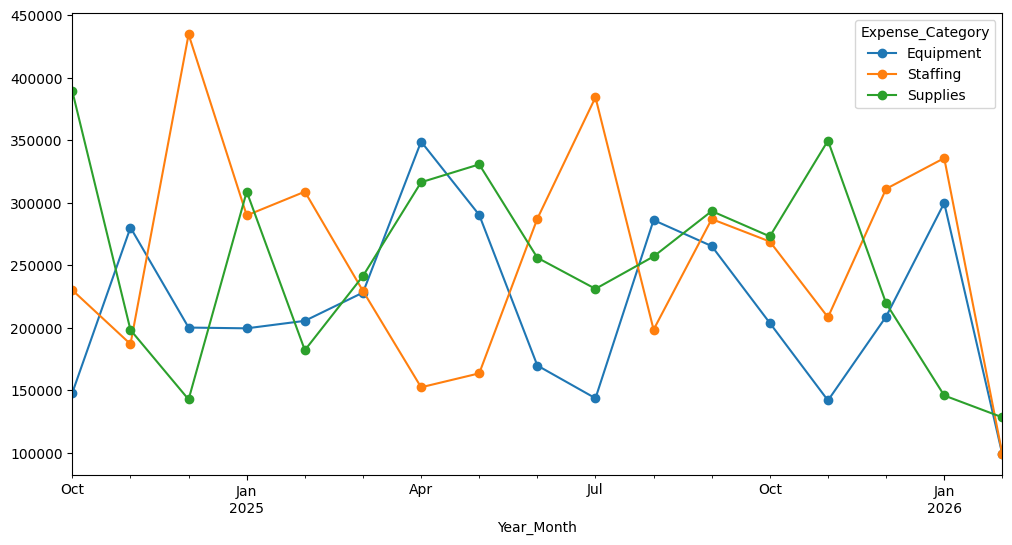

In [23]:
evolucao_gastos = df.groupby(['Year_Month', 'Expense_Category'])['Amount'].sum().unstack()
evolucao_gastos.plot(kind='line', marker='o', figsize=(12, 6))